# **Semi-structured dataset**: Amazon Fashion Reviews – JSON lines format combining text, numeric ratings, and product metadata

In [1]:
import pandas as pd
import gzip
import json

file_path = "C:/Users/Lenovo/Downloads/meta_Amazon_Fashion.jsonl.gz"

# Reading JSON Lines into a DataFrame
with gzip.open(file_path, 'rt', encoding='utf-8') as f:
    data = [json.loads(line) for line in f]

df = pd.DataFrame(data)
df.head(3)

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,AMAZON FASHION,YUEDGE 5 Pairs Men's Moisture Control Cushione...,4.6,16,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],GiveGift,[],{'Package Dimensions': '10.31 x 8.5 x 1.73 inc...,B08BHN9PK5,None
1,AMAZON FASHION,DouBCQ Women's Palazzo Lounge Wide Leg Casual ...,4.1,7,"[Drawstring closure, Machine Wash]",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],DouBCQ,[],{'Package Dimensions': '15 x 10.2 x 0.4 inches...,B08R39MRDW,None
2,AMAZON FASHION,Pastel by Vivienne Honey Vanilla Girls' Trapez...,4.3,11,"[Zipper closure, Hand Wash Only]",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Pastel by Vivienne,[],"{'Is Discontinued By Manufacturer': 'No', 'Pac...",B077KJHCJ4,None


In [2]:
# Checking the size of the dataset
df.shape

(826108, 14)

In [12]:
# Checking for unstructured text:
df[['title', 'description']].sample(10)

,title,description
359391,100% SILK Narrow NeckTie EXTRA Skinny CADET BL...,[]
270926,Nalie Sports Chicago Baseball Fans. The Curse ...,[]
281154,MAGICMK Women Good Vibes T-Shirt Long Sleeve C...,[]
147424,Boys' Short Sleeve Crewneck Tshirt Gaming t Sh...,[]
487450,Cancer Awareness Survivor Ribbon Pin - Kidney ...,[You are a survivor from the moment you hear t...
516449,Graduation Gifts for Her College Graduation Gi...,[Aching to show a woman just how much you valu...
504496,SKYVAN Punk Double Strap Heart Garter Elastic ...,[]
44824,pqdaysun Women's Casual Sundress Sleeveless St...,[]
658250,"LEEUEE 12 Pack Slap Bracelets for Kids, Silico...",[]
572555,Dannto Outdoor Winter Slippers for Men Women W...,[]


In [1]:
import pandas as pd
import numpy as np
import json
import gzip
from collections import Counter

file_path = "C:/Users/Lenovo/Downloads/meta_Amazon_Fashion.jsonl.gz"

# Reading JSON Lines into a DataFrame
with gzip.open(file_path, 'rt', encoding='utf-8') as f:
    data = [json.loads(line) for line in f]

df = pd.DataFrame(data)

# Calculate sparsity
sparsity = df.isna().mean().sort_values()

# Check if 'description' column exists
if 'description' in df.columns:
    # Mark rows with valid, non-empty list descriptions
    df['has_description'] = df['description'].apply(lambda x: isinstance(x, list) and len(x) > 0)

    # Combine description list to text string, handle NaN safely
    df['description_text'] = df['description'].apply(
        lambda x: ' '.join(x) if isinstance(x, list) else '')

    # Function to compute entropy
    def calc_entropy(text):
        if not text:
            return 0
        counter = Counter(text.split())
        probs = np.array(list(counter.values())) / sum(counter.values())
        return -np.sum(probs * np.log2(probs))

    df['entropy'] = df['description_text'].apply(calc_entropy)

    summary = {'rows_with_description': df['has_description'].sum(),
        'total_rows': len(df),
        'percent_with_description': df['has_description'].mean() * 100}
else:
    summary = "The 'description' field is missing from the data."

print('Sparsity:')
display(sparsity)
print('\nSummary:')
display(summary)
print('\nEntropy_description_stats')
display(df['entropy'].describe())

Sparsity:


main_category      0.000000
title              0.000000
average_rating     0.000000
rating_number      0.000000
features           0.000000
description        0.000000
images             0.000000
videos             0.000000
categories         0.000000
details            0.000000
parent_asin        0.000000
store              0.032487
price              0.939174
bought_together    1.000000
dtype: float64


Summary:


{'rows_with_description': 59289,
 'total_rows': 826108,
 'percent_with_description': 7.1769066514305635}


Entropy_description_stats


count    826108.000000
mean          0.382906
std           1.415927
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           8.843984
Name: entropy, dtype: float64

### **Visual Diagnostics**

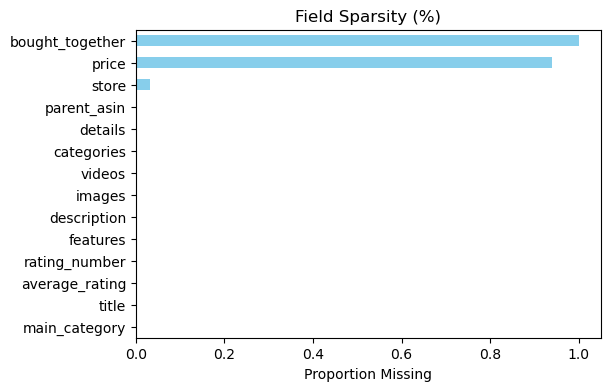

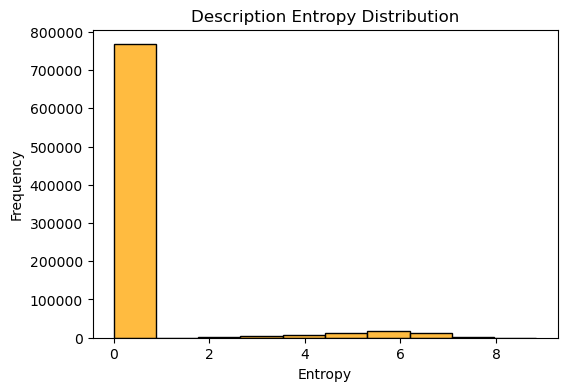

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Sparsity plot
plt.figure(figsize=(6, 4))
sparsity.plot(kind='barh', color='skyblue')
plt.title("Field Sparsity (%)")
plt.xlabel("Proportion Missing")
plt.show()

# 2) Entropy distribution for description
plt.figure(figsize=(6, 4))
sns.histplot(df['entropy'], bins=10, color='orange')
plt.title("Description Entropy Distribution")
plt.xlabel("Entropy")
plt.ylabel("Frequency")
plt.show()

## STEP 1. **Quantify variance & correlation**

### **For numeric:** average_rating, rating_number, price
#### - Calculate variance & standard deviation.
#### - Check for low-variance signals → candidate ballast.

### **For categorical:** store, main_category
#### - Cardinality check: how many unique?
#### - Top frequency vs tail → features with single dominant class may be ballast.

### **For nested lists:** features, categories
#### - Explode lists → count unique terms.
#### - TF-IDF: detect overly common phrases.

### 1️⃣ Variance & Standard Deviation for Numeric

In [2]:
import pandas as pd
import numpy as np
import gzip
import json

# === Load Data ===
with gzip.open("C:/Users/Lenovo/Downloads/meta_Amazon_Fashion.jsonl.gz", 'rt', encoding='utf-8') as f:
    data = [json.loads(line) for line in f]
df = pd.DataFrame(data)

# === Numeric fields ===
numeric_cols = ['average_rating', 'rating_number', 'price']

print("=== Variance & Standard Deviation ===")
for col in numeric_cols:
    col_series = df[col].fillna(0)
    var = col_series.var()
    std = col_series.std()
    print(f"{col}: Variance = {var:.4f} | Std Dev = {std:.4f} | Non-Null % = {(col_series != 0).mean()*100:.2f}%")

# === Pairwise Correlation ===
print("\n=== Pairwise Correlation Matrix ===")
corr = df[numeric_cols].fillna(0).corr()
print(corr)


=== Variance & Standard Deviation ===
average_rating: Variance = 0.9649 | Std Dev = 0.9823 | Non-Null % = 100.00%
rating_number: Variance = 49192.0149 | Std Dev = 221.7927 | Non-Null % = 100.00%
price: Variance = 1539.2788 | Std Dev = 39.2336 | Non-Null % = 6.08%

=== Pairwise Correlation Matrix ===
                average_rating  rating_number     price
average_rating        1.000000       0.018287  0.021085
rating_number         0.018287       1.000000  0.005040
price                 0.021085       0.005040  1.000000


### 2️⃣ Cardinality for Categorical

In [3]:
# === Categorical fields ===
cat_cols = ['store', 'main_category']

print("\n=== Cardinality & Dominance ===")
for col in cat_cols:
    unique_count = df[col].nunique(dropna=True)
    top_value = df[col].value_counts(normalize=True).iloc[0]
    print(f"{col}: Unique = {unique_count} | Top value share = {top_value:.2%}")
    print(df[col].value_counts().head(5))
    print("-" * 40)



=== Cardinality & Dominance ===
store: Unique = 89699 | Top value share = 0.64%
store
Nike           5154
Romwe          4150
GRACE KARIN    3833
Verdusa        3723
Floerns        3441
Name: count, dtype: int64
----------------------------------------
main_category: Unique = 1 | Top value share = 100.00%
main_category
AMAZON FASHION    826108
Name: count, dtype: int64
----------------------------------------


### 3️⃣ Nested Lists: Unique Terms & TF-IDF

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# === For 'features' ===
print("\n=== Unique terms in 'features' ===")
df['features_flat'] = df['features'].apply(lambda x: ' '.join(x) if isinstance(x, list) else '')

features_texts = df['features_flat'].tolist()
features_vectorizer = TfidfVectorizer(stop_words='english')
features_tfidf = features_vectorizer.fit_transform(features_texts)

print(f"Number of unique terms (features): {len(features_vectorizer.get_feature_names_out())}")
print("Top terms by mean TF-IDF weight:")
mean_tfidf = np.asarray(features_tfidf.mean(axis=0)).flatten()
top_idx = mean_tfidf.argsort()[::-1][:10]
for idx in top_idx:
    print(f"{features_vectorizer.get_feature_names_out()[idx]}: {mean_tfidf[idx]:.4f}")

# === For 'categories' ===
print("\n=== Unique terms in 'categories' ===")

# Join lists safely
df['categories_flat'] = df['categories'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else '')

# Remove rows with empty strings
categories_texts = df['categories_flat']
categories_texts = categories_texts[categories_texts.str.strip() != '']

# Make sure there’s at least one non-empty doc
if len(categories_texts) == 0:
    print("No non-empty categories to analyze.")
else:
    categories_vectorizer = TfidfVectorizer(stop_words='english')
    categories_tfidf = categories_vectorizer.fit_transform(categories_texts)

    print(f"Number of unique terms (categories): {len(categories_vectorizer.get_feature_names_out())}")
    print("Top terms by mean TF-IDF weight:")
    mean_tfidf_cat = np.asarray(categories_tfidf.mean(axis=0)).flatten()
    top_idx_cat = mean_tfidf_cat.argsort()[::-1][:10]
    for idx in top_idx_cat:
        print(f"{categories_vectorizer.get_feature_names_out()[idx]}: {mean_tfidf_cat[idx]:.4f}")



=== Unique terms in 'features' ===
Number of unique terms (features): 53308
Top terms by mean TF-IDF weight:
closure: 0.1054
wash: 0.0781
pull: 0.0701
hand: 0.0532
machine: 0.0440
100: 0.0303
polyester: 0.0279
cotton: 0.0277
button: 0.0258
zipper: 0.0254

=== Unique terms in 'categories' ===
No non-empty categories to analyze.


## STEP 2. **Compute MI**

### Goal

- Compute Mutual Information (MI) between each candidate feature and a target (`average_rating` or `rating_number`).
- Flag features with low MI → likely ballast.


In [1]:
import pandas as pd
import numpy as np
import gzip, json
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# === Load ===
with gzip.open("C:/Users/Lenovo/Downloads/meta_Amazon_Fashion.jsonl.gz", 'rt', encoding='utf-8') as f:
    data = [json.loads(line) for line in f]
df = pd.DataFrame(data)

# === Target ===
target = df['average_rating'].fillna(0)

# === Candidate features ===
# Already decided: skip main_category, skip categories
# Use: store, features, price

# --- Encode 'store' ---
le_store = LabelEncoder()
df['store_enc'] = le_store.fit_transform(df['store'].astype(str))

# --- Encode 'features' as mean TF-IDF ---
df['features_flat'] = df['features'].apply(lambda x: ' '.join(x) if isinstance(x, list) else '')
features_texts = df['features_flat']
features_texts = features_texts[features_texts.str.strip() != '']  # Remove empties

if len(features_texts) > 0:
    vectorizer = TfidfVectorizer(stop_words='english', max_features=500)
    features_tfidf = vectorizer.fit_transform(features_texts)
    features_mean_tfidf = features_tfidf.mean(axis=1).A1

    # Fill TF-IDF back in full df shape
    df['features_tfidf'] = 0.0  
    df.loc[features_texts.index, 'features_tfidf'] = features_mean_tfidf
else:
    df['features_tfidf'] = 0.0

# --- Fill NaNs ---
df['price'] = df['price'].fillna(0)

# === Build X ===
X = df[['store_enc', 'features_tfidf', 'price']]

# === Compute MI ===
mi = mutual_info_regression(X, target)

print("\n=== Mutual Information w.r.t average_rating ===")
for col, score in zip(X.columns, mi):
    print(f"{col}: MI = {score:.6f}")

# === Flag ballast candidates ===
threshold = 0.001  # near-zero MI

print("\n=== Ballast candidates based on MI ===")
for col, score in zip(X.columns, mi):
    if score < threshold:
        print(f"{col} → candidate ballast (MI = {score:.6f})")

# === Reminder of known ballast ===
print("\nKnown ballast (profiled earlier): main_category, categories")



=== Mutual Information w.r.t average_rating ===
store_enc: MI = 0.150922
features_tfidf: MI = 0.040431
price: MI = 0.004033

=== Ballast candidates based on MI ===

Known ballast (profiled earlier): main_category, categories


## STEP 3. **Pairwise correlation & redundancy flag**

This checks **numeric** & **ordinal** features, flags **redundancy**, and aligns with ***ballast rules***

In [2]:
import pandas as pd
import numpy as np
import gzip, json
from sklearn.preprocessing import LabelEncoder

# === Load Data ===
with gzip.open("C:/Users/Lenovo/Downloads/meta_Amazon_Fashion.jsonl.gz", 'rt', encoding='utf-8') as f:
    data = [json.loads(line) for line in f]
df = pd.DataFrame(data)

# === Prepare numeric & ordinal ===

# Encode 'store' to ordinal
le_store = LabelEncoder()
df['store_enc'] = le_store.fit_transform(df['store'].astype(str))

# Fill NaN for price
df['price'] = df['price'].fillna(0)

# Select relevant
numeric_cols = ['average_rating', 'rating_number', 'price', 'store_enc']

# === Compute pairwise correlation ===
corr_matrix = df[numeric_cols].corr()

print("\n=== Pairwise Correlation Matrix ===")
print(corr_matrix)

# === Flag any strong redundancy ===
threshold = 0.95

print("\n=== Highly Correlated Pairs (|corr| > 0.95) ===")
redundant_pairs = []
for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        corr_value = corr_matrix.iloc[i,j]
        if abs(corr_value) > threshold:
            pair = (numeric_cols[i], numeric_cols[j], corr_value)
            redundant_pairs.append(pair)
            print(f"{pair[0]} ↔ {pair[1]} : corr = {corr_value:.4f}")

if not redundant_pairs:
    print("No pairs with correlation above 0.95 — no redundant numerics found.")



=== Pairwise Correlation Matrix ===
                average_rating  rating_number     price  store_enc
average_rating        1.000000       0.018287  0.021085  -0.009186
rating_number         0.018287       1.000000  0.005040  -0.003191
price                 0.021085       0.005040  1.000000  -0.001686
store_enc            -0.009186      -0.003191 -0.001686   1.000000

=== Highly Correlated Pairs (|corr| > 0.95) ===
No pairs with correlation above 0.95 — no redundant numerics found.


## Step 4. **Textual Ballast Detection and Storage Impact Analysis**

- **Textual redundancy**: TF-IDF, LDA topic coherence

- **Semantic redundancy**: BERT similarity & clustering

- **Dimensionality**: PCA/t-SNE to test if features collapse

- **Storage impact**: Sparse formats vs dense → actual physical ballast

#### 1️⃣ TF-IDF on *'description'*

##### *TF-IDF* matrix shows if all descriptions look similar or trivial.

In [1]:
import pandas as pd
import numpy as np
import gzip, json
from sklearn.feature_extraction.text import TfidfVectorizer

# === Load Data ===
with gzip.open("C:/Users/Lenovo/Downloads/meta_Amazon_Fashion.jsonl.gz", 'rt', encoding='utf-8') as f:
    data = [json.loads(line) for line in f]
df = pd.DataFrame(data)

# Only keep rows with real descriptions
df['description_flat'] = df['description'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else '')
desc_texts = df[df['description_flat'].str.strip() != '']['description_flat']

print(f"Non-empty descriptions: {len(desc_texts)}")

vectorizer = TfidfVectorizer(stop_words='english', max_features=500)
tfidf_desc = vectorizer.fit_transform(desc_texts)

print(f"TF-IDF matrix shape: {tfidf_desc.shape}")
print(f"Top terms: {vectorizer.get_feature_names_out()[:10]}")


Non-empty descriptions: 59289
TF-IDF matrix shape: (59289, 500)
Top terms: ['10' '100' '11' '12' '13' '14' '15' '16' '17' '18']


### 2️⃣ LDA Topic Coherence

#### If topics are incoherent or trivial, *'description'* is ballast

In [2]:
from sklearn.decomposition import LatentDirichletAllocation

# LDA wants dense input, so convert sparse TF-IDF to dense (small sample)
lda_input = tfidf_desc[:1000].toarray()  # Example: 1000 rows
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(lda_input)

# Display top words per topic
terms = vectorizer.get_feature_names_out()
for idx, topic in enumerate(lda.components_):
    top_terms = [terms[i] for i in topic.argsort()[:-6:-1]]
    print(f"Topic #{idx}: {', '.join(top_terms)}")


Topic #0: quality, jewelry, products, best, shirt
Topic #1: comfort, shoes, support, foot, heel
Topic #2: silver, gift, necklace, bracelet, great
Topic #3: length, size, bust, sunglasses, lens
Topic #4: fabric, soft, fleece, bag, face


### 3️⃣ BERT embeddings for title similarity

#### High average similarity → titles may be redundant

In [3]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer('all-MiniLM-L6-v2')  # Lightweight

titles = df['title'].dropna().sample(1000, random_state=42).tolist()
title_embeddings = model.encode(titles, show_progress_bar=True)

# Cosine similarity matrix
cos_sim = cosine_similarity(title_embeddings)
print(f"Shape: {cos_sim.shape}")

# Average similarity to nearest neighbor
import numpy as np
nearest_sim = []
for row in cos_sim:
    sorted_row = np.sort(row)
    nearest_sim.append(sorted_row[-2])  # -1 is self-similarity = 1.0
print(f"Mean nearest title similarity: {np.mean(nearest_sim):.4f}")


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Shape: (1000, 1000)
Mean nearest title similarity: 0.6570


### 4️⃣ Clustering (K-Means / DBSCAN) on embeddings

#### Tiny clusters = outliers → possible noise or ballast

In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=42)
clusters = kmeans.fit_predict(title_embeddings)

print(f"Cluster counts: {np.bincount(clusters)}")


Cluster counts: [125  71  88  98 130  72 107 162  51  96]


### 5️⃣ PCA / t-SNE

#### If 1–2 components explain ~90% → rest might be ballast

Explained variance ratio: [0.07591858 0.04809764 0.03077629 0.02912486 0.02405486 0.02223856
 0.01955677 0.01926063 0.01794258 0.01670189]
Cumulative: [0.07591858 0.12401621 0.1547925  0.18391737 0.20797223 0.2302108
 0.24976757 0.26902822 0.2869708  0.30367267]


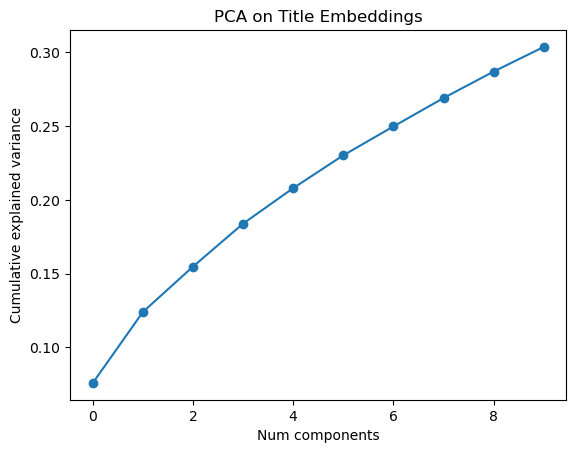

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=10)
pca.fit(title_embeddings)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))

# Quick plot
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Num components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA on Title Embeddings")
plt.show()


### 6️⃣ System impact & compression

In [6]:
import scipy.sparse as sp
import os

# Save original TF-IDF shape
print(f"TF-IDF non-zero elements: {tfidf_desc.nnz}")

# Save as CSR
csr = sp.csr_matrix(tfidf_desc)
sp.save_npz("desc_tfidf_csr.npz", csr)

# Save as dense (bad practice!)
dense = tfidf_desc.toarray()
np.save("desc_tfidf_dense.npy", dense)

# Compare file sizes
csr_size = os.path.getsize("desc_tfidf_csr.npz") / 1024
dense_size = os.path.getsize("desc_tfidf_dense.npy") / 1024

print(f"CSR file size: {csr_size:.2f} KB")
print(f"Dense file size: {dense_size:.2f} KB")
print(f"Sparsity savings: {100*(1 - csr_size/dense_size):.2f}%")


TF-IDF non-zero elements: 1161484
CSR file size: 9994.07 KB
Dense file size: 231597.78 KB
Sparsity savings: 95.68%


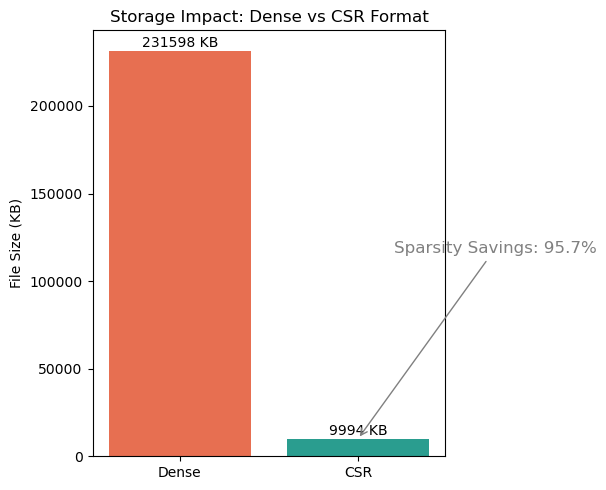

In [1]:
import matplotlib.pyplot as plt

# Results - 6️⃣ System impact & compression
dense_size = 231597.78  # KB
csr_size = 9994.07      # KB
savings_pct = 95.68

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
methods = ['Dense', 'CSR']
sizes = [dense_size, csr_size]
bars = ax.bar(methods, sizes, color=['#E76F51', '#2A9D8F'])

# Labels
for bar, size in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f"{size:.0f} KB", ha='center', fontsize=10)

# Annotation
ax.annotate(f"Sparsity Savings: {savings_pct:.1f}%",
            xy=(1, csr_size),
            xytext=(1.2, dense_size/2),
            arrowprops=dict(arrowstyle="->", color='gray'),
            fontsize=12, color='gray')

# Style
ax.set_ylabel("File Size (KB)")
ax.set_title("Storage Impact: Dense vs CSR Format")
plt.tight_layout()
plt.show()


##### **Fig. 1.** Comparison of storage size for the sparse description field vectorized with TF-IDF. Using the Compressed Sparse Row (CSR) format reduces physical storage requirements by 95.68% compared to a dense representation, confirming the effectiveness of sparse formats for minimizing ballast overhead in semi-structured text data

## STEP 5. **Visual Diagnostics**

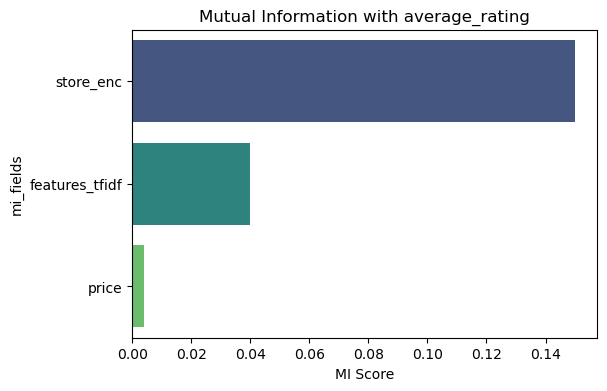

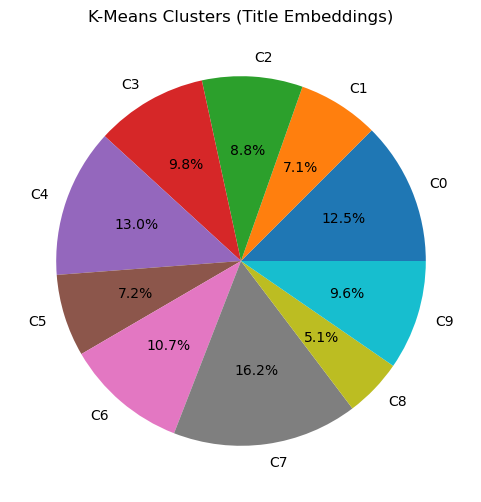

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# MI bar plot
mi_scores = [0.15, 0.04, 0.004]
mi_fields = ['store_enc', 'features_tfidf', 'price']

df = pd.DataFrame({'mi_scores': mi_scores, 'mi_fields': mi_fields, 'hue': mi_fields})  # Unique hue per bar

plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='mi_scores', y='mi_fields', hue='hue', dodge=False, palette='viridis', legend=False)
plt.title("Mutual Information with average_rating")
plt.xlabel("MI Score")
plt.show()

# Clustering results (example pie chart)
cluster_counts = [125, 71, 88, 98, 130, 72, 107, 162, 51, 96]
plt.figure(figsize=(6, 6))
plt.pie(cluster_counts, labels=[f'C{i}' for i in range(10)], autopct='%1.1f%%')
plt.title("K-Means Clusters (Title Embeddings)")
plt.show()


### **Final Mask Summary**

In [1]:
# Columns for ML
keep_columns = [
    'store',            # encoded
    'features',         # filter generic phrases
    'title',            # deduplicated clusters if needed
    'average_rating',   # target
    'rating_number']

# Optional test columns
optional_columns = ['price']

# Columns you DROP
ballast_columns = ['main_category', 'categories', 'description']

print("   Final ballast mask ready:")
print("Keep columns:", keep_columns)
print("Drop columns:", ballast_columns)
print("Optional test columns:", optional_columns)


   Final ballast mask ready:
Keep columns: ['store', 'features', 'title', 'average_rating', 'rating_number']
Drop columns: ['main_category', 'categories', 'description']
Optional test columns: ['price']


## Phase 2.1. **Ballast Detection and Reduction** 
### (Entropy + MI + Redundancy mask + LightGBM trade-off)


1️⃣ **Uses `CountVectorizer` to get raw text counts for features.**  
   - Extracts term-document matrix from raw text data.  
   - Produces sparse matrix representatin.

2️⃣ **Computes normalized entropy for each term.**  
   - Measures distribution uncertainty across documents.  
   - Normalized to [0, 1] for comparaility.

3️⃣ **Computes normalized Mutual Information (MI) with your target (`average_rating_bin`).**  
   - Quantifies relevance of each term to the target variable.  
   - Normalized for interpetability.

4️⃣ **Computes pairwise cosine similarity to flag near-duplicate redundant terms.**  
   - Identifies highly similar terms.  
   - Flags redundant features for potntial removal.

5️⃣ **Builds a combined ballast mask:**  
   - Drops terms with **low entropy AND low MI OR redundancy**.  
   - Balances information loss wih noise reduction.

6️⃣ **Runs LightGBM for each threshold:**  
   - Evaluates impact of ballast removal on model performance.  
   - Tracks feature count reduction and system resource savings.  
   - Saves the full dimension msk for reproducibility.

7️⃣ **Plots your final ballast-performance trade-off curve.**  
   - Visualizes how ballast removal affects model accuracy and efficiency.  
   - Helps determineoptimal reduction threshold.



=== Top terms by normalized entropy ===
[('closure', 0.9140511936219264), ('wash', 0.8785076323632792), ('pull', 0.8493698331703122), ('hand', 0.8365229040764135), ('machine', 0.8217621519400474), ('100', 0.8105988266560971), ('polyester', 0.801096866265822), ('cotton', 0.7958444923100764), ('button', 0.7641607696785729), ('zipper', 0.7609299183171193)]

=== Example term MI scores ===
10: 0.0678
100: 0.9382
11: 0.0925
12: 0.1210
13: 0.0628
14: 0.0267
15: 0.0327
16: 0.0444
18: 0.1296
20: 0.0607

Found 1 redundant pairs with cosine sim >= 0.95
Example redundant pairs: [('licensed', 'officially', 0.9606135694763409)]

=== Numeric feature entropies (normalized) ===
{'store_enc': 0.995395968529727, 'rating_number': 0.0010784039323015711, 'price': 0.00042686869515751435}

Threshold 0.00 | Numeric: ['store_enc', 'rating_number', 'price'] | Text terms kept: 499
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.142992 seconds.
You can set `force_row_wise=t

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Threshold 0.90 | Numeric: ['store_enc'] | Text terms kept: 3
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025750 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 273
[LightGBM] [Info] Number of data points in the train set: 660886, number of used features: 4
[LightGBM] [Info] Start training from score -2.697441
[LightGBM] [Info] Start training from score -2.239630
[LightGBM] [Info] Start training from score -1.077268
[LightGBM] [Info] Start training from score -0.722371


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



=== Final robust Phase 2 Results ===
    threshold  num_numeric  num_terms  accuracy        f1  \
0        0.00            3        499  0.530389  0.474658   
1        0.05            1        499  0.494238  0.378893   
2        0.10            1        499  0.494238  0.378893   
3        0.15            1        499  0.494238  0.378893   
4        0.20            1        499  0.494238  0.378893   
5        0.25            1        499  0.494238  0.378893   
6        0.30            1        499  0.494238  0.378893   
7        0.35            1        499  0.494238  0.378893   
8        0.40            1        499  0.494238  0.378893   
9        0.45            1        497  0.494323  0.379342   
10       0.50            1        476  0.494619  0.380089   
11       0.55            1        378  0.495043  0.381392   
12       0.60            1        166  0.494256  0.378905   
13       0.65            1         60  0.493621  0.375635   
14       0.70            1         23  0.494631

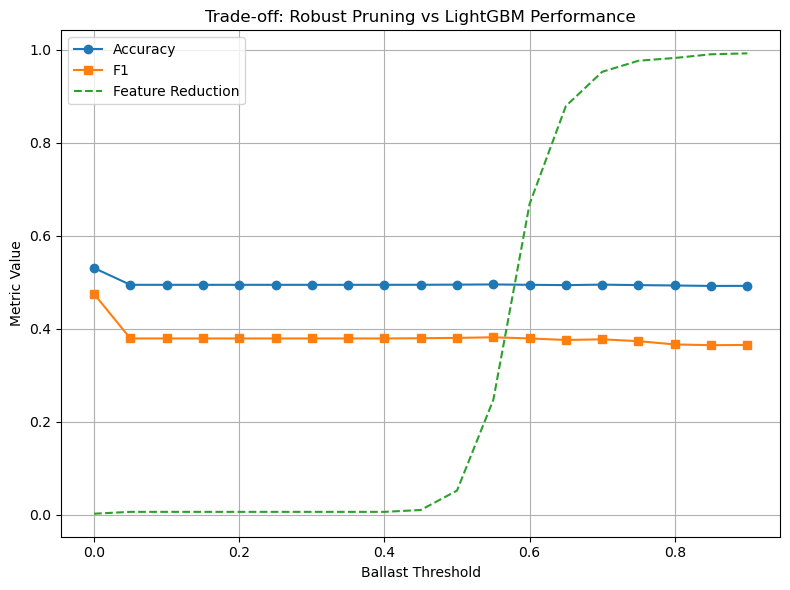

In [1]:
import pandas as pd
import numpy as np
import gzip, json, time
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import lightgbm as lgb
from scipy.sparse import hstack
import json
import matplotlib.pyplot as plt

# === Load dataset ===
with gzip.open("C:/Users/Lenovo/Downloads/meta_Amazon_Fashion.jsonl.gz", 'rt', encoding='utf-8') as f:
    data = [json.loads(line) for line in f]
df = pd.DataFrame(data)

# === Basic encoding ===
df['store_enc'] = LabelEncoder().fit_transform(df['store'].astype(str))
df['rating_number'] = df['rating_number'].fillna(0)
df['price'] = df['price'].fillna(0)

# === Vectorize text ===
df['features_flat'] = df['features'].apply(lambda x: ' '.join(x) if isinstance(x, list) else '')

count_vectorizer = CountVectorizer(stop_words='english', max_features=500)
count_matrix = count_vectorizer.fit_transform(df['features_flat'])
count_terms = count_vectorizer.get_feature_names_out()

# === Compute normalized entropy ===
def calc_entropy(col):
    if np.count_nonzero(col) == 0:
        return 0
    probs = col[col > 0] / col.sum()
    return -np.sum(probs * np.log2(probs))

term_entropy = []
for i in range(count_matrix.shape[1]):
    col = count_matrix[:, i].toarray().flatten()
    term_entropy.append(calc_entropy(col))

max_entropy = np.log2(count_matrix.shape[0])
normalized_entropy = [e / max_entropy for e in term_entropy]

print("\n=== Top terms by normalized entropy ===")
print(sorted(zip(count_terms, normalized_entropy), key=lambda x: x[1], reverse=True)[:10])

# === Compute normalized Mutual Information ===
df['average_rating_bin'] = pd.cut(df['average_rating'], bins=[0,2,3,4,5], labels=[0,1,2,3])
y_bin = df['average_rating_bin']
X_terms_dense = count_matrix.toarray()

mi_scores = mutual_info_classif(X_terms_dense, y_bin, discrete_features=True)
mi_normalized = mi_scores / np.max(mi_scores)

print("\n=== Example term MI scores ===")
for i in range(10):
    print(f"{count_terms[i]}: {mi_normalized[i]:.4f}")

# === Compute pairwise cosine similarity ===
cos_sim = cosine_similarity(X_terms_dense.T)
redundant_pairs = []
threshold_sim = 0.95

for i in range(len(count_terms)):
    for j in range(i+1, len(count_terms)):
        if cos_sim[i, j] >= threshold_sim:
            redundant_pairs.append((count_terms[i], count_terms[j], cos_sim[i, j]))

redundant_terms = set(pair[1] for pair in redundant_pairs)

print(f"\nFound {len(redundant_pairs)} redundant pairs with cosine sim >= {threshold_sim}")
print("Example redundant pairs:", redundant_pairs[:5])

# === Compute numeric entropy (normalized) ===
def calc_numeric_entropy(arr, bins=10):
    hist, _ = np.histogram(arr, bins=bins)
    probs = hist / hist.sum()
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

numeric_features = ['store_enc', 'rating_number', 'price']
numeric_entropy = {}
for col in numeric_features:
    e = calc_numeric_entropy(df[col].values)
    numeric_entropy[col] = e / np.log2(10)

print("\n=== Numeric feature entropies (normalized) ===")
print(numeric_entropy)

# === Robust pruning loop ===
results = []
thresholds = np.arange(0, 0.95, 0.05)

for t in thresholds:
    selected_numeric = [f for f in numeric_features if numeric_entropy[f] >= t]

    # robust mask for terms: (entropy >= t OR MI >= t) AND not redundant
    selected_term_idx = []
    for i, term in enumerate(count_terms):
        ent = normalized_entropy[i]
        mi = mi_normalized[i]
        if ((ent >= t) or (mi >= t)) and term not in redundant_terms:
            selected_term_idx.append(i)
    selected_terms = [count_terms[i] for i in selected_term_idx]

    print(f"\nThreshold {t:.2f} | Numeric: {selected_numeric} | Text terms kept: {len(selected_terms)}")

    if len(selected_numeric) + len(selected_terms) == 0:
        print("Skipping — no features left.")
        continue

    X_num = df[selected_numeric].astype(np.float32).values if selected_numeric else None
    X_text = count_matrix[:, selected_term_idx].astype(np.float32) if selected_term_idx else None

    if X_num is not None and X_text is not None:
        X_all = hstack([X_text, X_num])
    elif X_text is not None:
        X_all = X_text
    else:
        X_all = X_num

    y = df['average_rating_bin']
    X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)

    model = lgb.LGBMClassifier()
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')

    storage_KB = X_all.data.nbytes / 1024 if hasattr(X_all, 'data') else X_all.nbytes / 1024
    feature_reduction_pct = 100 * (1 - (len(selected_numeric) + len(selected_terms)) / (len(numeric_features) + len(count_terms)))

    results.append({
        'threshold': t,
        'num_numeric': len(selected_numeric),
        'num_terms': len(selected_terms),
        'accuracy': acc,
        'f1': f1,
        'precision': prec,
        'recall': rec,
        'train_time_sec': train_time,
        'feature_reduction_pct': feature_reduction_pct,
        'storage_KB': storage_KB,
        'kept_numeric': selected_numeric,
        'kept_terms': selected_terms
    })

    # Save mask
    with open(f'robust_mask_t{t:.2f}.json', 'w') as f:
        json.dump({'numeric': selected_numeric, 'terms': selected_terms}, f, indent=2)

print("\n=== Final robust Phase 2 Results ===")
results_df = pd.DataFrame(results)
print(results_df[['threshold', 'num_numeric', 'num_terms', 'accuracy', 'f1', 'feature_reduction_pct']])
results_df.to_csv('robust_phase2_results.csv', index=False)

# === Trade-off plot ===
plt.figure(figsize=(8, 6))
plt.plot(results_df['threshold'], results_df['accuracy'], label='Accuracy', marker='o')
plt.plot(results_df['threshold'], results_df['f1'], label='F1', marker='s')
plt.plot(results_df['threshold'], results_df['feature_reduction_pct']/100, label='Feature Reduction', linestyle='--')
plt.xlabel("Ballast Threshold")
plt.ylabel("Metric Value")
plt.title("Trade-off: Robust Pruning vs LightGBM Performance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Scatter plot of **Normalized Entropy** vs. **Normalized MI**

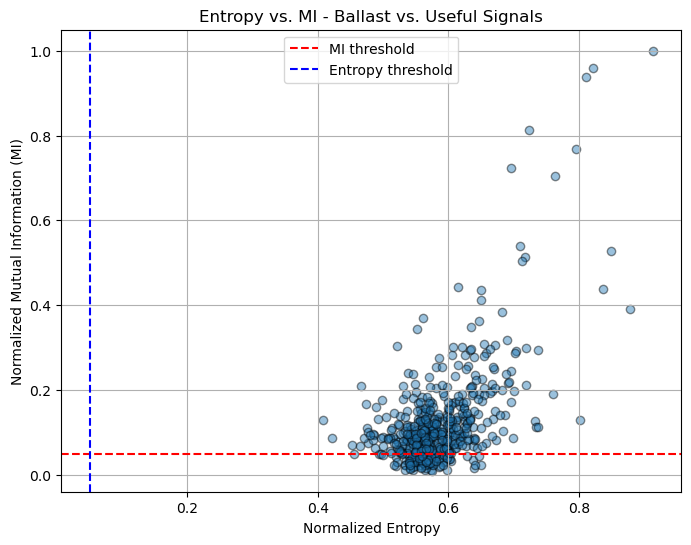

In [7]:
import matplotlib.pyplot as plt

# Data: normalized_entropy, mi_normalized from my results
plt.figure(figsize=(8, 6))
plt.scatter(normalized_entropy, mi_normalized, alpha=0.45, edgecolor='k')

plt.axhline(0.05, color='red', linestyle='--', label='MI threshold')
plt.axvline(0.05, color='blue', linestyle='--', label='Entropy threshold')

plt.xlabel("Normalized Entropy")
plt.ylabel("Normalized Mutual Information (MI)")
plt.title("Entropy vs. MI - Ballast vs. Useful Signals")
plt.grid(True)
plt.legend()
plt.show()


###  **How to interpret it**
#### **Bottom-left quadrant:** terms to drop → low variation, no predictive power.
#### **Top-left:** rare, but possible — low entropy, high MI → maybe very strong signal (e.g., unique brand terms).
#### **Top-right:** keep → diverse and predictive.
#### **Bottom-right:** noisy → watch for redundancy.

## Phase 2.2. **Multi-Signal Ballast Detection & Reduction**

**Signals Used:**
- Entropy (TF-IDF mean)
- Mutual Information (MI, binarized)
- LDA Topic Coherence
- Info Bottleneck (MI × Entropy)
- BERT Semantic Redundancy (sample-based)
- TF-IDF Term Redundancy (cosine)
- Optional: PCA to visualize collapse

**Goal:** Evaluate trade-off between ballast pruning and model utility (LightGBM).

In [1]:
import pandas as pd
import numpy as np
import gzip, json, time
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import lightgbm as lgb
from scipy.sparse import hstack
import json
import matplotlib.pyplot as plt

### 1️⃣ Load Dataset

In [2]:
import pandas as pd
import gzip, json

with gzip.open("meta_Amazon_Fashion.jsonl.gz", 'rt', encoding='utf-8') as f:
    data = [json.loads(line) for line in f]
df = pd.DataFrame(data)
df['features_flat'] = df['features'].apply(lambda x: ' '.join(x) if isinstance(x, list) else '')
print(f"✅ Loaded {len(df)} rows.")

✅ Loaded 826108 rows.


### 2️⃣ TF-IDF + Entropy

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_features=500)
tfidf_matrix = vectorizer.fit_transform(df['features_flat'])
tfidf_terms = vectorizer.get_feature_names_out()
tfidf_mean = tfidf_matrix.mean(axis=0).A1
print(f"✅ TF-IDF shape: {tfidf_matrix.shape}")


✅ TF-IDF shape: (826108, 500)


### 3️⃣ Mutual Information (Binarized)

In [4]:
from sklearn.feature_selection import mutual_info_classif
import numpy as np

df['average_rating_bin'] = pd.cut(df['average_rating'], bins=[0,2,3,4,5], labels=[0,1,2,3])
y = df['average_rating_bin']
X_tfidf_binary = (tfidf_matrix.toarray() > 0).astype(int)
mi_scores = mutual_info_classif(X_tfidf_binary, y, discrete_features=True)
mi_normalized = mi_scores / np.max(mi_scores)
print(f"✅ Example MI scores: {mi_normalized[:5]}")


✅ Example MI scores: [0.05725943 0.86769507 0.08208251 0.10709094 0.06143889]


### 4️⃣ LDA Topic Coherence

In [5]:
from gensim import corpora, models

texts = [f.split() for f in df['features_flat']]
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]
lda = models.LdaModel(corpus=corpus, id2word=dictionary, num_topics=5, passes=5)
coherence_model = models.CoherenceModel(model=lda, texts=texts, dictionary=dictionary, coherence='c_v')

term_coherence = {}
for term in tfidf_terms:
    tid = dictionary.token2id.get(term)
    if tid:
        scores = []
        for topic in lda.show_topics(num_topics=-1, formatted=False):
            if term in [w for w, _ in topic[1]]:
                scores.append(coherence_model.get_coherence())
        term_coherence[term] = np.mean(scores) if scores else 0.0
    else:
        term_coherence[term] = 0.0
print(f"✅ Example LDA: {list(term_coherence.items())[:5]}")


✅ Example LDA: [('10', 0.0), ('100', 0.0), ('11', 0.0), ('12', 0.0), ('13', 0.0)]


### 5️⃣ BERT Semantic Redundancy (Safe Sample)

In [6]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import DBSCAN

sample_texts = df['features_flat'].dropna().sample(10000, random_state=42).tolist()
bert_model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = bert_model.encode(sample_texts, batch_size=64, show_progress_bar=True)

mean_sim = np.mean(cosine_similarity(embeddings))
print(f"✅ BERT mean sim (sample): {mean_sim:.4f}")

clustering = DBSCAN(eps=0.7, min_samples=2, metric='cosine').fit(embeddings)
labels = clustering.labels_
print(f"✅ Redundant clusters: {np.sum(labels != -1)}")
bert_signal = mean_sim


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

✅ BERT mean sim (sample): 0.3159
✅ Redundant clusters: 9997


### 6️⃣ Term Redundancy (TF-IDF Cosine)

In [7]:
term_cos_sim = cosine_similarity(tfidf_matrix.T)
redundant_terms = set()
for i in range(len(tfidf_terms)):
    for j in range(i+1, len(tfidf_terms)):
        if term_cos_sim[i,j] > 0.9:
            redundant_terms.add(tfidf_terms[j])
print(f"✅ Term-level redundancy: {len(redundant_terms)}")


✅ Term-level redundancy: 3


### 6️⃣' Plotting Term-Term Cosine Similarity

Total term pairs: 124750


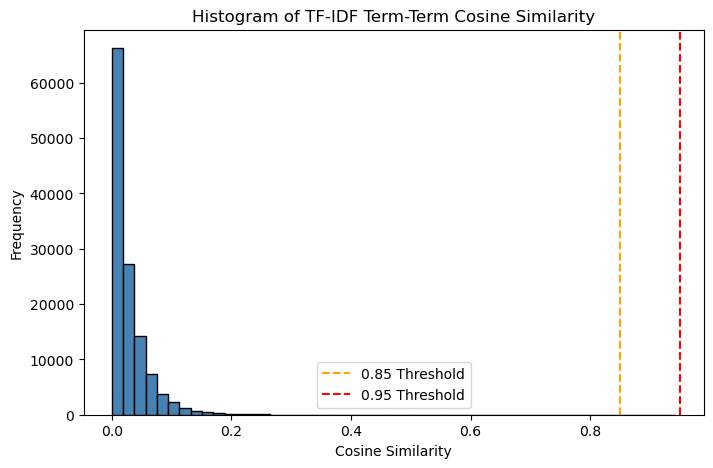

Mean: 0.0280 | Median: 0.0169
Pairs > 0.85: 4
Pairs > 0.95: 0


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Compute pairwise term similarity
term_cos_sim = cosine_similarity(tfidf_matrix.T)

# Get the upper triangle (excluding diagonal)
mask = np.triu(np.ones(term_cos_sim.shape), k=1).astype(bool)
term_sim_values = term_cos_sim[mask]

print(f"Total term pairs: {len(term_sim_values)}")

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(term_sim_values, bins=50, color='steelblue', edgecolor='black')
plt.title("Histogram of TF-IDF Term-Term Cosine Similarity")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.axvline(0.85, color='orange', linestyle='--', label='0.85 Threshold')
plt.axvline(0.95, color='red', linestyle='--', label='0.95 Threshold')
plt.legend()
plt.show()

# Basic stats
print(f"Mean: {term_sim_values.mean():.4f} | Median: {np.median(term_sim_values):.4f}")
print(f"Pairs > 0.85: {(term_sim_values > 0.85).sum()}")
print(f"Pairs > 0.95: {(term_sim_values > 0.95).sum()}")


### 7️⃣ Info Bottleneck & PCA

##### We used ***TruncatedSVD*** to estimate the intrinsic dimensionality and information bottleneck, avoiding the dense matrix memory overhead of classic ***PCA***

In [9]:
info_bottleneck = [mi_normalized[i] * tfidf_mean[i] for i in range(len(tfidf_terms))]

# TruncatedSVD on sparse matrix
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=20, random_state=42)
svd.fit(tfidf_matrix)

print(f"✅ TruncatedSVD explained variance ratio: {svd.explained_variance_ratio_}")
print(f"✅ TruncatedSVD cumulative: {np.cumsum(svd.explained_variance_ratio_)}")


✅ TruncatedSVD explained variance ratio: [0.12833683 0.10317895 0.05717658 0.0493988  0.04685839 0.03708974
 0.03586    0.02870567 0.02763951 0.0205932  0.01816357 0.0177103
 0.01458089 0.01495046 0.01472872 0.01316584 0.01267969 0.01096735
 0.00998363 0.00940459]
✅ TruncatedSVD cumulative: [0.12833683 0.23151578 0.28869236 0.33809117 0.38494956 0.4220393
 0.4578993  0.48660498 0.51424449 0.53483768 0.55300125 0.57071155
 0.58529244 0.6002429  0.61497162 0.62813746 0.64081714 0.6517845
 0.66176813 0.67117271]


### 8️⃣ Phase 2 Pruning Loop

#### Output:
##### - *multi_signal_phase2_results.csv*
##### - Trade-off curve
##### - Save JSON masks for each threshold

In [10]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import time

results = []
thresholds = np.arange(0, 0.95, 0.05)

for t in thresholds:
    keep_idx = []

    for i, term in enumerate(tfidf_terms):
        tfidf_val = tfidf_mean[i]
        mi_val = mi_normalized[i]
        coherence_val = term_coherence.get(term, 0.0)
        ib_val = info_bottleneck[i]

        # If we computed BERT cosine similarity for redundancy:
        bert_sim = max_sim[term] if 'max_sim' in globals() else 0.0  # or our BERT signal array

        keep = (((tfidf_val >= t) or (mi_val >= t) or (coherence_val >= t) or (ib_val >= t))
            and bert_sim < 0.8                #  Only keep if not near-duplicate
            and term not in redundant_terms)  #  Drop co-occurrence redundant pairs
        
        if keep:
            keep_idx.append(i)

    selected_terms = [tfidf_terms[i] for i in keep_idx]
    print(f"\n      Threshold {t:.2f} | Kept terms: {len(selected_terms)}")

    if not selected_terms:
        continue

    X_text = tfidf_matrix[:, keep_idx].astype(np.float32)
    X_train, X_test, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)

    model = lgb.LGBMClassifier()
    start = time.time()
    model.fit(X_train, y_train)
    duration = time.time() - start

    y_pred = model.predict(X_test)

    results.append({'threshold': t,
        'num_terms': len(selected_terms),
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred, average='weighted'),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall': recall_score(y_test, y_pred, average='weighted'),
        'train_time_sec': duration,
        'feature_reduction_pct': 100 * (1 - len(selected_terms)/len(tfidf_terms))})

    # Save mask for this threshold
    with open(f"multi_signal_mask_t{t:.2f}.json", "w") as f:
        json.dump({"terms": selected_terms}, f, indent=2)

# Save final results
pd.DataFrame(results).to_csv("multi_signal_phase2_results.csv", index=False)
print("\n     Phase 2 pruning finish. Results saved.")



      Threshold 0.00 | Kept terms: 497
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.170212 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 101656
[LightGBM] [Info] Number of data points in the train set: 660886, number of used features: 497
[LightGBM] [Info] Start training from score -2.697441
[LightGBM] [Info] Start training from score -2.239630
[LightGBM] [Info] Start training from score -1.077268
[LightGBM] [Info] Start training from score -0.722371

      Threshold 0.05 | Kept terms: 342
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.738025 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 73507
[LightGBM] [Info] Number of data points in the train set: 660886, number of used features: 342
[LightGBM] [Info] Start training from score -2.697441
[

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



      Threshold 0.80 | Kept terms: 3
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033402 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 742
[LightGBM] [Info] Number of data points in the train set: 660886, number of used features: 3
[LightGBM] [Info] Start training from score -2.697441
[LightGBM] [Info] Start training from score -2.239630
[LightGBM] [Info] Start training from score -1.077268
[LightGBM] [Info] Start training from score -0.722371


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



      Threshold 0.85 | Kept terms: 3
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.049790 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 742
[LightGBM] [Info] Number of data points in the train set: 660886, number of used features: 3
[LightGBM] [Info] Start training from score -2.697441
[LightGBM] [Info] Start training from score -2.239630
[LightGBM] [Info] Start training from score -1.077268
[LightGBM] [Info] Start training from score -0.722371


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



      Threshold 0.90 | Kept terms: 2
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031427 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 493
[LightGBM] [Info] Number of data points in the train set: 660886, number of used features: 2
[LightGBM] [Info] Start training from score -2.697441
[LightGBM] [Info] Start training from score -2.239630
[LightGBM] [Info] Start training from score -1.077268
[LightGBM] [Info] Start training from score -0.722371

     Phase 2 pruning finish. Results saved.


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 9️⃣ Trade-off Curve

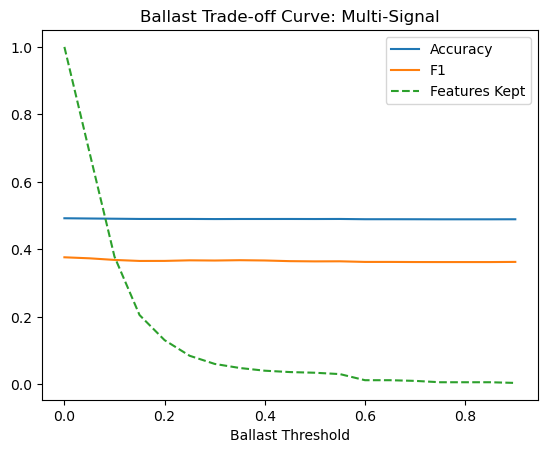

In [11]:
import matplotlib.pyplot as plt
df_results = pd.DataFrame(results)
plt.plot(df_results['threshold'], df_results['accuracy'], label='Accuracy')
plt.plot(df_results['threshold'], df_results['f1'], label='F1')
plt.plot(df_results['threshold'], df_results['num_terms']/max(df_results['num_terms']), label='Features Kept', linestyle='--')
plt.xlabel('Ballast Threshold')
plt.title('Ballast Trade-off Curve: Multi-Signal')
plt.legend()
plt.show()


### 9️⃣' Final Trade-off Curve: Performance vs Ballast Reduction

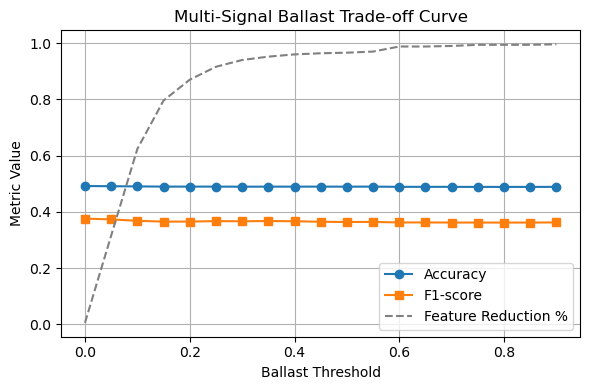

    threshold  num_terms  accuracy        f1  precision    recall  \
0        0.00        497  0.492132  0.376427   0.475203  0.492132   
1        0.05        342  0.491418  0.373397   0.462696  0.491418   
2        0.10        188  0.490758  0.368591   0.490396  0.490758   
3        0.15        102  0.490068  0.365582   0.467918  0.490068   
4        0.20         65  0.490038  0.365713   0.461706  0.490038   
5        0.25         42  0.490068  0.367412   0.451059  0.490068   
6        0.30         30  0.489747  0.366817   0.443657  0.489747   
7        0.35         24  0.489929  0.367807   0.449333  0.489929   
8        0.40         20  0.489947  0.366957   0.468307  0.489947   
9        0.45         18  0.489983  0.364978   0.464365  0.489983   
10       0.50         17  0.489856  0.364292   0.454272  0.489856   
11       0.55         15  0.490019  0.364525   0.447037  0.490019   
12       0.60          6  0.489263  0.362696   0.456613  0.489263   
13       0.65          6  0.489263

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your results
results_df = pd.read_csv("multi_signal_phase2_results.csv")

# Create the plot
plt.figure(figsize=(6,4))

# Model metrics
plt.plot(results_df['threshold'], results_df['accuracy'], label='Accuracy', marker='o')
plt.plot(results_df['threshold'], results_df['f1'], label='F1-score', marker='s')

# Ballast reduction
plt.plot(
    results_df['threshold'], 
    results_df['feature_reduction_pct']/100, 
    label='Feature Reduction %', 
    linestyle='--',
    color='gray')

plt.xlabel("Ballast Threshold")
plt.ylabel("Metric Value")
plt.title("Multi-Signal Ballast Trade-off Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print summary
print(results_df)
